# 日経レバ1579：月曜日アノマリー（シカゴ連動型）バックテスト

元ネタ：[Nikkei 225 Trading Strategy: Free Money Edge](https://breakouttradingacademy.com/this-strategy-is-like-printing-free-money-nikkei-225/)

## 戦略ロジック
シカゴ市場の月曜日（日本時間の月曜夜〜火曜早朝）に発生する日経平均先物の強力な上昇バイアスを、日本市場のETF（1579.T）で利益に変える戦略です。

*   **エントリー**: 月曜日の大引け（15:00）で成行買い
*   **エグジット**: 火曜日の寄付き（09:00）で成行売り
*   **目的**: シカゴの月曜セッションでの上昇を「窓開け」として取り込む。

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Meiryo', 'Yu Gothic', 'Hiragino Maru Gothic Pro', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def load_moomoo_csv(filepath):
    df = pd.read_csv(filepath, thousands=',')
    column_map = {'日付': 'Date', '始値': 'Open', '高値': 'High', '安値': 'Low', '終値': 'Close'}
    df = df.rename(columns=column_map)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    return df

In [9]:
# データ読み込み（1579.T）
data_path_1579 = "../../moomoo/data/TimeChart(1579)20130509_20260502.csv"
df = load_moomoo_csv(data_path_1579)

# 2018年以降に限定（元ネタが指摘する近年の傾向を確認）
df = df[df.index >= "2018-01-01"]
df['day_of_week'] = df.index.dayofweek

## 1. 戦略の検証：月曜引け買い → 火曜寄り売り

このトレードのリターンは、**「火曜日の始値 - 月曜日の終値」**になります。
※日本株市場では火曜日のデータ（Open）に、月曜日のシカゴの動きが反映されます。

In [10]:
# 月曜日の終値を取得
monday_close = df[df['day_of_week'] == 0]['Close']

# 火曜日の始値を取得
tuesday_open = df[df['day_of_week'] == 1]['Open']

# 日付を合わせてリターンを計算（月曜日に買って火曜日に売る）
# monday_closeのインデックスは月曜、tuesday_openは火曜なので、
# tuesday_openを1日前にシフトして日付を合わせます
backtest_df = pd.DataFrame({
    'Buy_Price': monday_close,
    'Sell_Price': tuesday_open.shift(-1, freq='D') # 火曜のOpenを月曜の行に持ってくる
}).dropna()

backtest_df['Return'] = (backtest_df['Sell_Price'] - backtest_df['Buy_Price']) / backtest_df['Buy_Price']

print(f"検証回数: {len(backtest_df)}回")
print(f"勝率: {(backtest_df['Return'] > 0).mean():.2%}")
print(f"平均リターン: {backtest_df['Return'].mean():.4%}")
print(f"合計リターン: {backtest_df['Return'].sum():.2%}")

検証回数: 360回
勝率: 61.39%
平均リターン: 0.4664%
合計リターン: 167.89%


## 2. 他の曜日との比較（オーバーナイト）

「◯曜日の引けに買い、翌営業日の寄付きで売る」というトレードを全曜日で比較します。

C:\Users\user\AppData\Local\Temp\ipykernel_27180\399848143.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison.index, y=comparison['平均リターン'], palette='viridis')


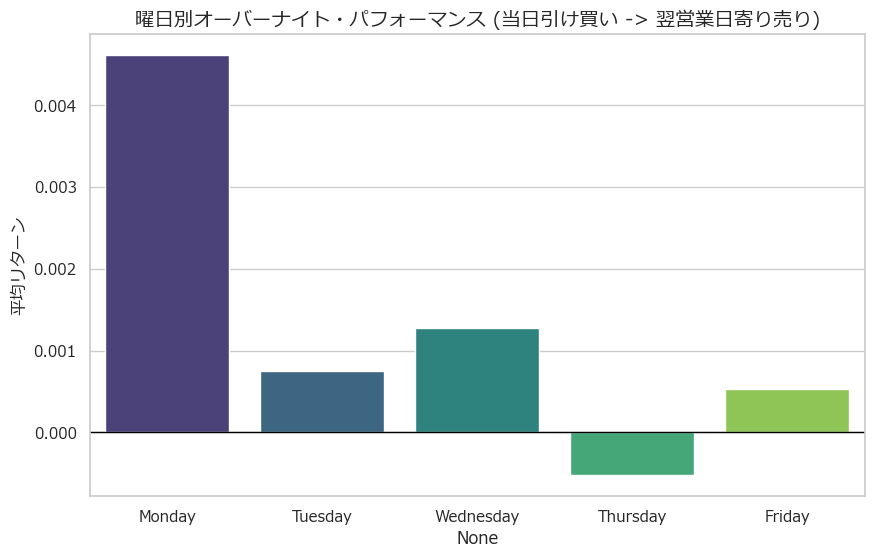

,平均リターン,勝率
Monday,0.461%,61.022%
Tuesday,0.075%,48.792%
Wednesday,0.128%,50.240%
Thursday,-0.052%,55.556%
Friday,0.053%,55.181%


In [11]:
df['next_open'] = df['Open'].shift(-1) # 翌営業日の始値
df['overnight_ret'] = (df['next_open'] - df['Close']) / df['Close']

weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
comparison = df.groupby('day_of_week')['overnight_ret'].agg(['mean', lambda x: (x > 0).mean()])
comparison.index = weekday_names
comparison.columns = ['平均リターン', '勝率']

plt.figure(figsize=(10, 6))
sns.barplot(x=comparison.index, y=comparison['平均リターン'], palette='viridis')
plt.title('曜日別オーバーナイト・パフォーマンス (当日引け買い -> 翌営業日寄り売り)', fontsize=14)
plt.axhline(0, color='black', lw=1)
plt.show()

display(comparison.style.format("{:.3%}"))

## 3. 累積リターンの推移

月曜日の大引けにだけ仕込み続けた場合の資産曲線を描画します。

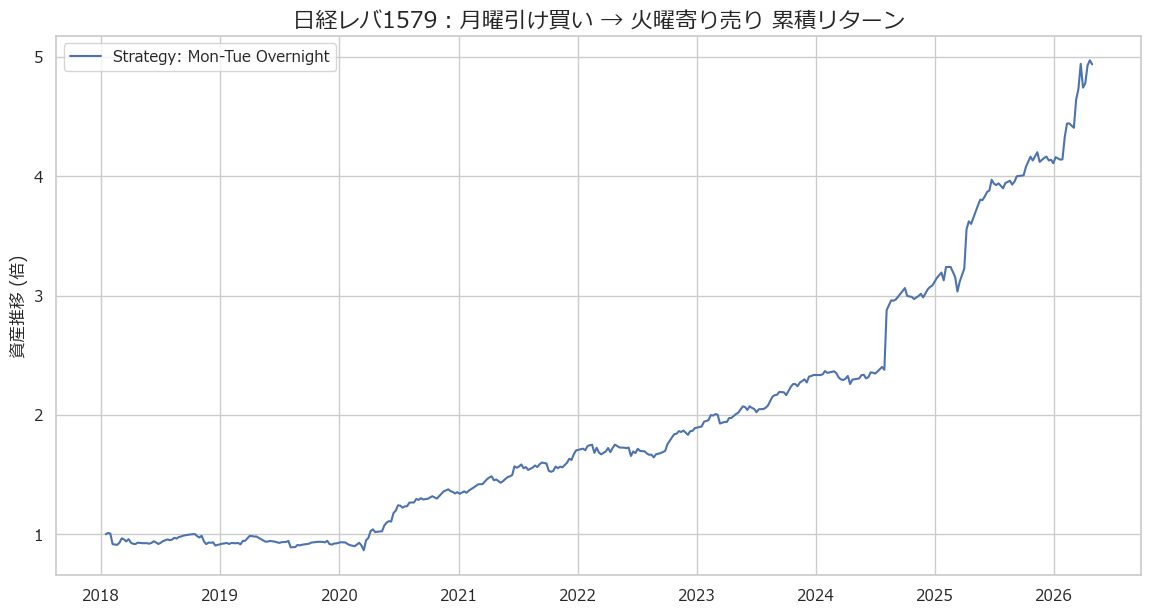

In [12]:
backtest_df['Equity'] = (1 + backtest_df['Return']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(backtest_df.index, backtest_df['Equity'], label='Strategy: Mon-Tue Overnight')
plt.title('日経レバ1579：月曜引け買い → 火曜寄り売り 累積リターン', fontsize=16)
plt.ylabel('資産推移 (倍)')
plt.legend()
plt.show()

## 結論

- 元ネタの通り、月曜日から火曜日にかけてのオーバーナイトに優位性があるか確認してください。
- もしこの曲線が綺麗に右肩上がりであれば、シカゴ市場の月曜日バイアスが日本市場に「窓開け」として波及していることの証明になります。

## 4. 2025年以降のパフォーマンス検証

直近の2025年からの推移を詳しく確認します。

--- 2025年以降の統計 ---
検証回数: 55回
勝率: 69.09%
平均リターン: 0.8845%


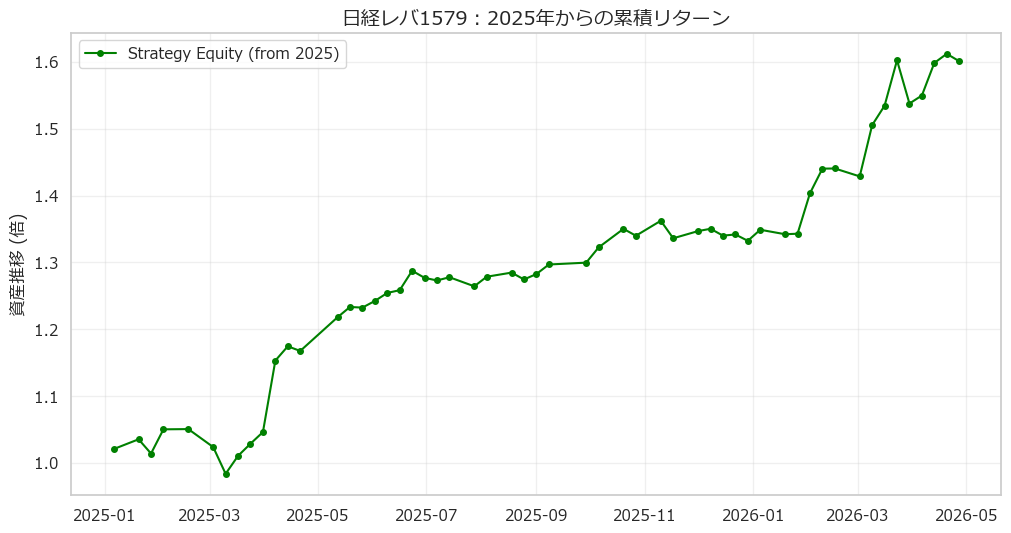

In [13]:
# 2025年以降にデータをフィルタリング
df_2025 = df[df.index >= "2025-01-01"].copy()

# 月曜引け買い → 火曜寄り売りリターンの再計算
monday_close_2025 = df_2025[df_2025['day_of_week'] == 0]['Close']
tuesday_open_2025 = df_2025[df_2025['day_of_week'] == 1]['Open']

bt_df_2025 = pd.DataFrame({
    'Buy': monday_close_2025,
    'Sell': tuesday_open_2025.shift(-1, freq='D')
}).dropna()

bt_df_2025['Return'] = (bt_df_2025['Sell'] - bt_df_2025['Buy']) / bt_df_2025['Buy']
bt_df_2025['Equity'] = (1 + bt_df_2025['Return']).cumprod()

print(f"--- 2025年以降の統計 ---")
print(f"検証回数: {len(bt_df_2025)}回")
print(f"勝率: {(bt_df_2025['Return'] > 0).mean():.2%}")
print(f"平均リターン: {bt_df_2025['Return'].mean():.4%}")

plt.figure(figsize=(12, 6))
plt.plot(bt_df_2025.index, bt_df_2025['Equity'], label='Strategy Equity (from 2025)', color='green', marker='o', markersize=4)
plt.title('日経レバ1579：2025年からの累積リターン', fontsize=14)
plt.ylabel('資産推移 (倍)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

■ 最大連勝数: 9連勝
■ 最大連敗数: 5連敗


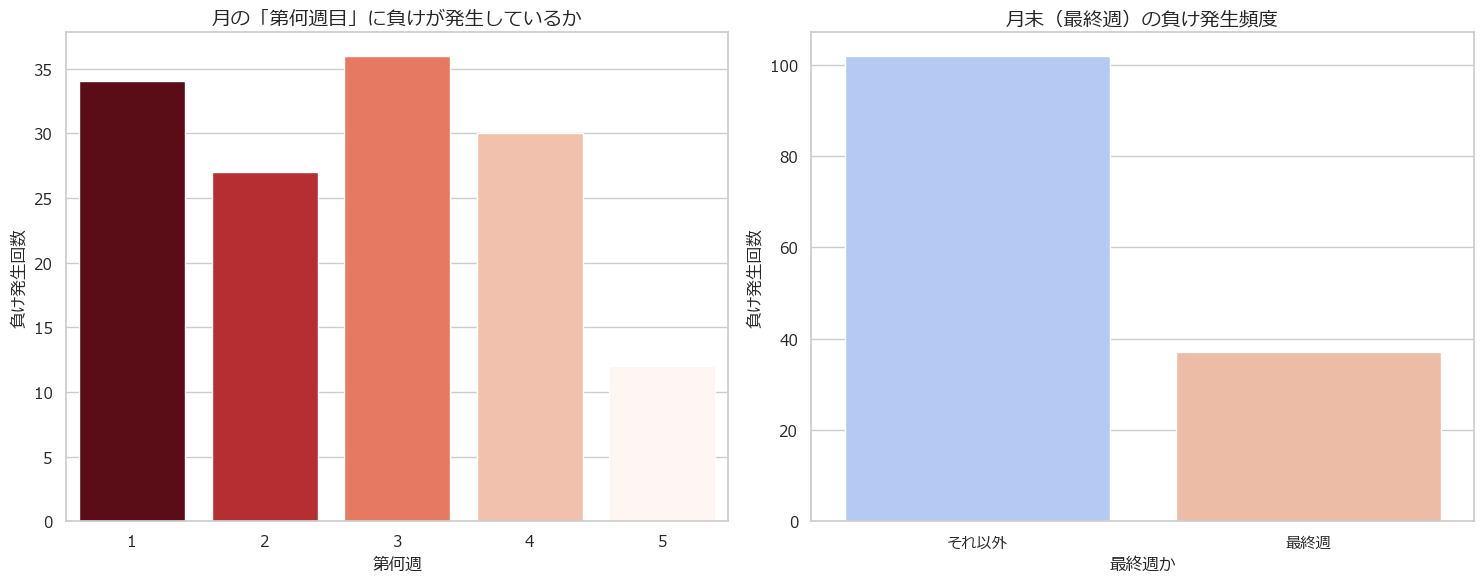

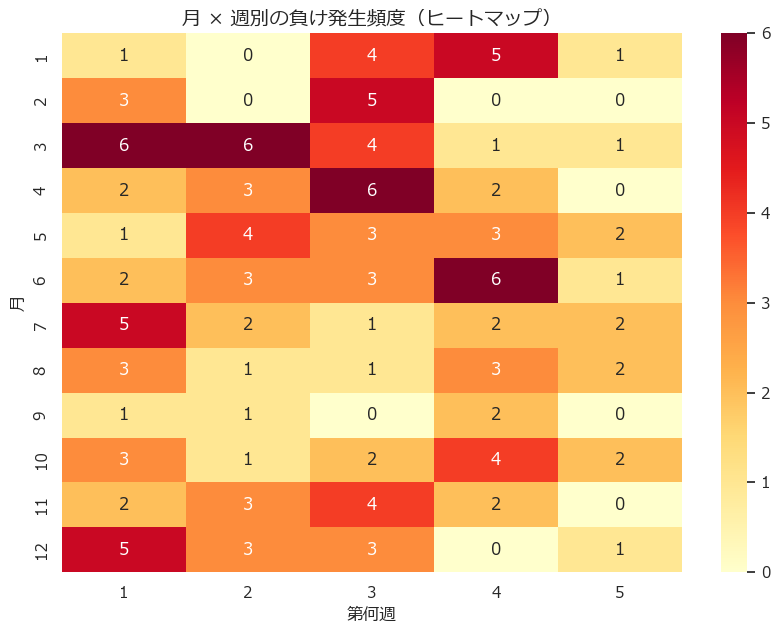


■ 負けた日の詳細一覧 (上位30件表示)


,Return,第何週,最終週か
Date,,,
2024-03-11,-1.49%,2,それ以外
2024-03-18,-0.73%,3,それ以外
2024-03-25,-0.18%,4,最終週
2024-04-15,-2.90%,3,それ以外
2024-06-03,-1.28%,1,それ以外
2024-06-24,-0.13%,4,最終週
2024-07-01,-0.29%,1,それ以外
2024-07-29,-0.98%,5,最終週
2024-08-26,-0.11%,4,最終週


In [14]:
# 連勝・連敗および負けた日の詳細分析（可視化追加）
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 連勝・連敗の計算
def calc_streaks(returns):
    wins = returns > 0
    win_streaks = wins.groupby((wins != wins.shift()).cumsum()).cumsum()
    max_win = win_streaks[wins].max() if any(wins) else 0
    
    losses = returns <= 0
    loss_streaks = losses.groupby((losses != losses.shift()).cumsum()).cumsum()
    max_loss = loss_streaks[losses].max() if any(losses) else 0
    
    return int(max_win), int(max_loss)

max_win, max_loss = calc_streaks(backtest_df['Return'])

print(f"■ 最大連勝数: {max_win}連勝")
print(f"■ 最大連敗数: {max_loss}連敗")

# 2. 負けた日のリストアップと週情報の計算
losses_df = backtest_df[backtest_df['Return'] <= 0].copy()

def get_week_of_month(date):
    """月の第何週目かを取得 (1日から始まる週)"""
    return (date.day - 1) // 7 + 1

def check_last_week(date):
    """その月の最終週（月末7日間）かどうか"""
    last_day = date + pd.offsets.MonthEnd(0)
    return "最終週" if (last_day.day - date.day) < 7 else "それ以外"

losses_df['第何週'] = losses_df.index.map(get_week_of_month)
losses_df['最終週か'] = losses_df.index.map(check_last_week)

# --- グラフ化 ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Meiryo', 'Yu Gothic', 'Hiragino Maru Gothic Pro', 'sans-serif']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# A. 第何週目に負けが多いか
sns.countplot(data=losses_df, x='第何週', ax=axes[0], palette='Reds_r', hue='第何週', legend=False)
axes[0].set_title('月の「第何週目」に負けが発生しているか', fontsize=14)
axes[0].set_ylabel('負け発生回数')

# B. 最終週の負け割合
sns.countplot(data=losses_df, x='最終週か', ax=axes[1], palette='coolwarm', hue='最終週か', legend=False)
axes[1].set_title('月末（最終週）の負け発生頻度', fontsize=14)
axes[1].set_ylabel('負け発生回数')

plt.tight_layout()
plt.show()

# C. 月 × 週のヒートマップ（負けの集中度を可視化）
losses_df['月'] = losses_df.index.month
pivot_table = losses_df.pivot_table(index='月', columns='第何週', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='d')
plt.title('月 × 週別の負け発生頻度（ヒートマップ）', fontsize=14)
plt.xlabel('第何週')
plt.ylabel('月')
plt.show()

print("\n■ 負けた日の詳細一覧 (上位30件表示)")
result_display = losses_df[['Return', '第何週', '最終週か']].copy()
result_display['Return'] = result_display['Return'].map(lambda x: f"{x:.2%}")
display(result_display.tail(30)) # 最新の負け傾向を見るため最後の方を表示